# Practice Set 15: Capstone Visualizations

**Objective:** Create three publication-quality visualizations that support your capstone project's narrative.

---

## Learning Objectives
By completing this problem set, you will:
- Select appropriate visualization types for different data and questions
- Apply ggplot2 best practices for clear, effective communication
- Create visualizations that tell a coherent story about your data
- Write captions that help readers interpret your figures

---

## Instructions

1. **Use your own capstone data** for all three visualizations
2. Each visualization should serve a **different purpose** (see requirements below)
3. All visualizations must include:
   - Clear, descriptive title
   - Labeled axes with units where appropriate
   - Legend (if applicable)
   - Clean theme (e.g., `theme_minimal()`, `theme_bw()`)
4. Write a brief caption (2-3 sentences) explaining what each visualization shows

---

## Setup
Load the required packages and your capstone data.

In [1]:
# Load packages
library(tidyverse)
library(scales)      # For nice axis formatting
library(ggthemes)    # Optional: additional themes

# Load your capstone data
fly_ash_data <- read_csv("../02_processed_data/epd_data_fly_ash.csv")
coal_plant_data <- read_csv("../02_processed_data/active_coal_plants_US.csv")

# Preview your data
#glimpse(fly_ash_data)
glimpse(coal_plant_data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor


Rows: 3940 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (11): gwp, id, gwp_per_category_declared_unit, concrete_compressive_str...
dbl   (7): uncertainty_factor, plant_or_group.latitude, plant_or_group.longi...
lgl   (1): lightweight
dttm

Rows: 391
Columns: 48
$ Database                              <chr> "July 2025", "July 2025", "July …
$ `GEM unit/phase ID`                   <chr> "G100000100057", "G100000100058"…
$ `GEM location ID`                     <chr> "L100000104168", "L100000104168"…
$ `Country/Area`                        <chr> "United States", "United States"…
$ `Wiki URL`                            <chr> "https://www.gem.wiki/AES_Puerto…
$ `Plant name`                          <chr> "AES Puerto Rico power station",…
$ `Unit name`                           <chr> "Unit 1", "Unit 2", "--", "Unit …
$ `Plant name (other)`                  <chr> NA, NA, NA, "John E Amos power s…
$ `Plant name (local)`                  <lgl> NA, NA, NA, NA, NA, NA, NA, NA, …
$ Owner                                 <chr> "AES Corp [100%]", "AES Corp [10…
$ `Owner GEM Entity ID`                 <chr> "E100000001305 [100%]", "E100000…
$ Parent                                <chr> "AES Corp [100.0%]", "AES Corp […
$ `Parent GEM Enti

---

## Visualization 1: Distribution or Composition (15 points)

**Purpose:** Show how your data is distributed or composed.

### Suggested plot types:
- **Histogram** – distribution of a continuous variable
- **Density plot** – smoothed distribution
- **Boxplot** – distribution across groups
- **Bar chart** – counts or proportions of categories
- **Pie/donut chart** – composition (use sparingly)

### Requirements:
- [ ] Shows the distribution OR composition of at least one key variable
- [ ] Includes appropriate title and axis labels
- [ ] Uses color meaningfully (not just decoratively)
- [ ] Caption explains what pattern or insight the reader should notice

### Questions to consider:
- What is the shape of your data's distribution? (Normal? Skewed? Bimodal?)
- Are there outliers that need explanation?
- How do distributions differ across groups?

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


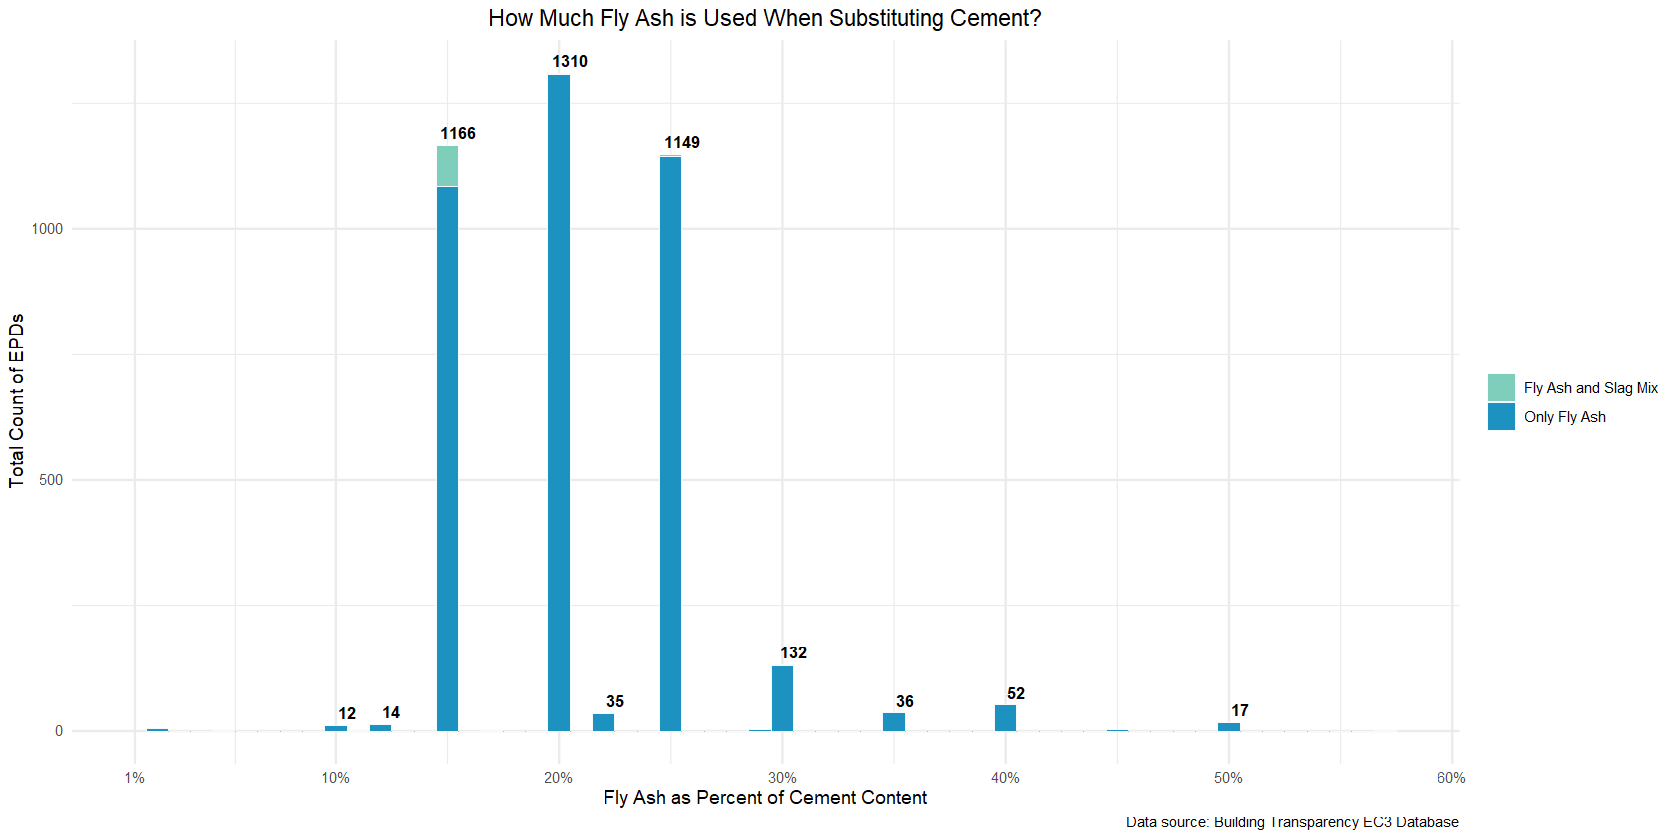

In [2]:
# VISUALIZATION 1: Distribution or Composition

# Set figure size for Jupyter display
options(repr.plot.width = 14, repr.plot.height = 7)

# Classify mixes by slag presence
fly_ash_plot_data <- fly_ash_data %>%
  mutate(mix_type = factor(
    if_else(!is.na(`cementitious.ggbs`) & `cementitious.ggbs` > 0,
            "Fly Ash and Slag Mix",
            "Only Fly Ash"),
    levels = c("Fly Ash and Slag Mix", "Only Fly Ash")
  ))

# Pre-compute bin totals; label bars with count > 10
label_data <- fly_ash_plot_data %>%
  mutate(bin_center = (floor(`cementitious.fly_ash` / 0.01 + 1e-9) * 0.01) + 0.005) %>%
  count(bin_center, name = "total") %>%
  filter(total > 10)

viz1 <- ggplot(fly_ash_plot_data, aes(x = `cementitious.fly_ash`, fill = mix_type)) +
  geom_histogram(binwidth = 0.01, color = "white", linewidth = 0.2) +
  geom_text(
    data = label_data,
    aes(x = bin_center, y = total, label = total),
    inherit.aes = FALSE,
    vjust = -0.5,
    size = 3.5,
    fontface = "bold"
  ) +
  scale_fill_manual(
    values = c("Only Fly Ash" = "#1d91c0", "Fly Ash and Slag Mix" = "#7fcdbb"),
    name = NULL
  ) +
  scale_x_continuous(
    limits = c(0.01, NA),
    breaks = c(0.01, seq(0.10, 0.60, by = 0.10)),
    labels = percent_format(accuracy = 1)
  ) +
  labs(
    title = "How Much Fly Ash is Used When Substituting Cement?",
    x = "Fly Ash as Percent of Cement Content",
    y = "Total Count of EPDs",
    caption = "Data source: Building Transparency EC3 Database"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

viz1

In [3]:
### use ggsave to save viz1 to the tests folder
ggsave("../tests/M15_viz1.png", viz1, width = 14, height = 7, dpi = 300)

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


### Caption for Visualization 1
This visualization is useful for me to see what percentage of cement (by mass) is being replaced by fly ash when fly ash is used as a subsititute for cement. This will allow be to focus on some of the more common concrete mix designs based on real world data rather than hypothetical percentages, which is a common approach taken in some of the existing research I've seen. This chart may not be of much interest to my audience at the end of the day, but it is a helpful tool for me to justify where I decide to focus my efforts.

**Figure 1:** How Much Fly Ash is Used When Substituting Cement?



---

## Visualization 2: Relationship or Comparison (15 points)

**Purpose:** Show a relationship between variables OR compare groups.

### Suggested plot types:
- **Scatterplot** – relationship between two continuous variables
- **Line plot** – trends over time or sequence
- **Grouped bar chart** – comparing categories across groups
- **Faceted plots** – same relationship across subgroups
- **Correlation heatmap** – relationships among multiple variables

### Requirements:
- [ ] Shows a relationship between at least two variables OR compares groups
- [ ] Includes appropriate title and axis labels
- [ ] Uses `geom_smooth()`, trend lines, or reference lines if appropriate
- [ ] Caption explains the relationship or comparison and its significance

### Questions to consider:
- Is the relationship positive, negative, or nonlinear?
- Are there subgroups that behave differently?
- What is the practical significance of this relationship for your capstone question?

Warning message:
"The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead."


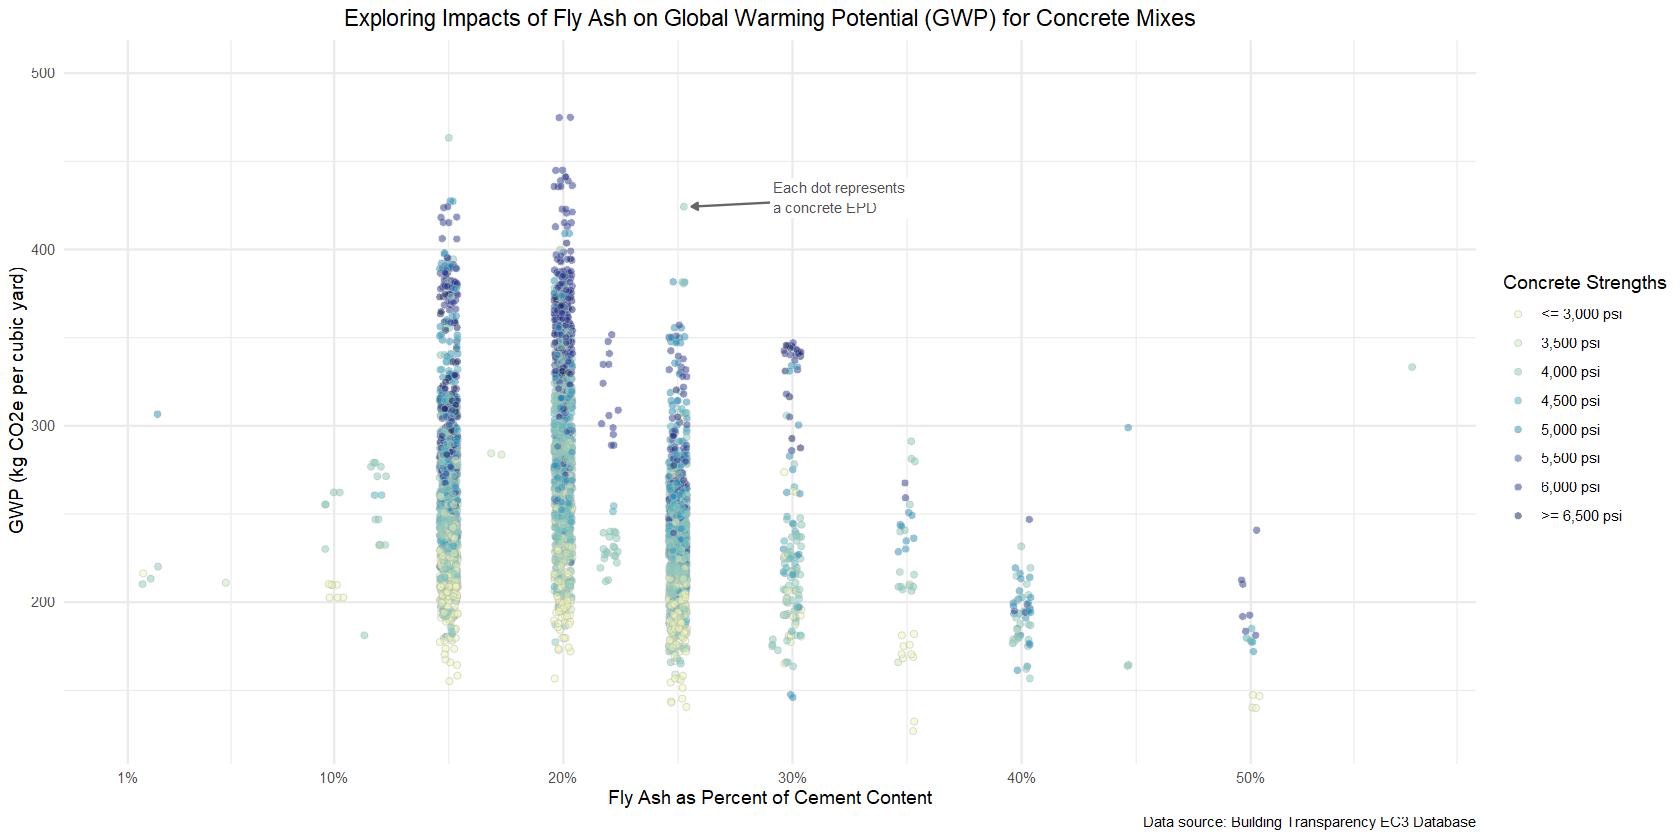

In [4]:
# VISUALIZATION 2: Relationship or Comparison

# Set figure size for Jupyter display
options(repr.plot.width = 14, repr.plot.height = 7)

# Define strength bucket levels and colors
strength_levels <- c("<= 3,000 psi", "3,500 psi", "4,000 psi", "4,500 psi",
                     "5,000 psi", "5,500 psi", "6,000 psi", ">= 6,500 psi")

strength_colors <- c(
  "<= 3,000 psi" = "#edf8b1",
  "3,500 psi"    = "#c7e9b4",
  "4,000 psi"    = "#7fcdbb",
  "4,500 psi"    = "#41b6c4",
  "5,000 psi"    = "#1d91c0",
  "5,500 psi"    = "#225ea8",
  "6,000 psi"    = "#253494",
  ">= 6,500 psi" = "#081d58"
)

# Prepare data: classify strength into buckets
fly_ash_viz2 <- fly_ash_data %>%
  mutate(
    strength_bucket = factor(
      case_when(
        Compressive_Strength <= 3000 ~ "<= 3,000 psi",
        Compressive_Strength <= 3500 ~ "3,500 psi",
        Compressive_Strength <= 4000 ~ "4,000 psi",
        Compressive_Strength <= 4500 ~ "4,500 psi",
        Compressive_Strength <= 5000 ~ "5,000 psi",
        Compressive_Strength <= 5500 ~ "5,500 psi",
        Compressive_Strength <= 6000 ~ "6,000 psi",
        TRUE                          ~ ">= 6,500 psi"
      ),
      levels = strength_levels
    )
  )

# Find the highest GWP point in the 25% fly ash bucket for annotation
tag_point <- fly_ash_viz2 %>%
  filter(abs(`cementitious.fly_ash` - 0.25) < 0.001) %>%
  slice_max(gwp_val_per_cy, n = 1)

viz2 <- ggplot(fly_ash_viz2, aes(x = `cementitious.fly_ash`, y = gwp_val_per_cy)) +
  geom_jitter(
    aes(fill = strength_bucket),
    shape = 21,
    color = "grey70",
    stroke = 0.3,
    width = 0.004,
    alpha = 0.5,
    size = 1.5
  ) +
  geom_curve(
    data = tag_point,
    aes(
      x    = `cementitious.fly_ash` + 0.08,
      y    = gwp_val_per_cy + 5,
      xend = `cementitious.fly_ash` + 0.006,
      yend = gwp_val_per_cy
    ),
    inherit.aes = FALSE,
    arrow     = arrow(length = unit(0.15, "cm"), type = "closed"),
    color     = "grey40",
    curvature = 0.0,
  ) +
  geom_label(
    data = tag_point,
    aes(
      x     = `cementitious.fly_ash` + 0.04,
      y     = gwp_val_per_cy + 5,
      label = "Each dot represents\na concrete EPD"
    ),
    inherit.aes = FALSE,
    hjust      = 0,
    size       = 3,
    fill       = "white",
    color      = "grey30",
    label.size = 0
  ) +
  scale_fill_manual(
    values = strength_colors,
    name = "Concrete Strengths"
  ) +
  scale_x_continuous(
    limits = c(0.01, NA),
    breaks = c(0.01, seq(0.10, 0.60, by = 0.10)),
    labels = percent_format(accuracy = 1)
  ) +
  coord_cartesian(ylim = c(NA, 500)) +
  labs(
    title = "Exploring Impacts of Fly Ash on Global Warming Potential (GWP) for Concrete Mixes",
    x = "Fly Ash as Percent of Cement Content",
    y = "GWP (kg CO2e per cubic yard)",
    caption = "Data source: Building Transparency EC3 Database"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

viz2

In [5]:
### use ggsave to save viz2 to the tests folder
ggsave("../tests/M15_viz2.png", viz2, width = 14, height = 7, dpi = 300)

### Caption for Visualization 2
This visualization helps to show the relationship between fly ash percentage and Global Warming Potential (GWP). Additionally, through the use of color, the relationship with a third variable is introduced, which is concrete strength. This is helpful to visualize the distribution of impacts based on fly ash percentage and concrete strength.

**Figure 2:** Exploring Impacts of Fly Ash on Global Warming Potential (GWP) for Concrete Mixes

---

## Visualization 3: Change Over Time or Space (15 points)

**Purpose:** Show how something changes across time, geography, or another ordered dimension.

### Suggested plot types:
- **Line chart** – trends over time
- **Area chart** – cumulative changes over time
- **Map** – spatial patterns (if you have geographic data)
- **Slope chart** – change between two time points
- **Faceted time series** – trends across multiple groups

### Requirements:
- [ ] Shows change across time, space, or another meaningful sequence
- [ ] Time axis is properly formatted (if applicable)
- [ ] Key events, thresholds, or reference points are annotated (if relevant)
- [ ] Caption explains the trend and its implications for your capstone

### Questions to consider:
- Is there a clear trend (increasing, decreasing, cyclical)?
- Are there notable events or breakpoints?
- How does this temporal/spatial pattern connect to your research question?

In [6]:
# Filter down EPD data set to only unique lat and long combinations (i.e. unique facilities)
concrete_plants <- fly_ash_data %>%
  filter(
    !is.na(`plant_or_group.latitude`),
    !is.na(`plant_or_group.longitude`),
    `plant_or_group.latitude`  >= 24.5 & `plant_or_group.latitude`  <= 49.5,
    `plant_or_group.longitude` >= -125  & `plant_or_group.longitude` <= -66.5
  ) %>%
  distinct(`plant_or_group.latitude`, `plant_or_group.longitude`)

#preview the first few rows of the filtered dataframe
print(concrete_plants)

# A tibble: 145 × 2
   plant_or_group.latitude plant_or_group.longitude
                     <dbl>                    <dbl>
 1                    37.5                    -122.
 2                    37.0                    -122.
 3                    36.7                    -122.
 4                    36.6                    -122.
 5                    37.4                    -122.
 6                    47.5                    -122.
 7                    37.7                    -122.
 8                    37.7                    -122.
 9                    37.3                    -122.
10                    37.5                    -122.
# ℹ 135 more rows


In [7]:
#Add additional mapping libraries here
library(maps)   # Provides map_data() for US state boundaries (required by ggplot2)


Attaching package: 'maps'


The following object is masked from 'package:purrr':

    map




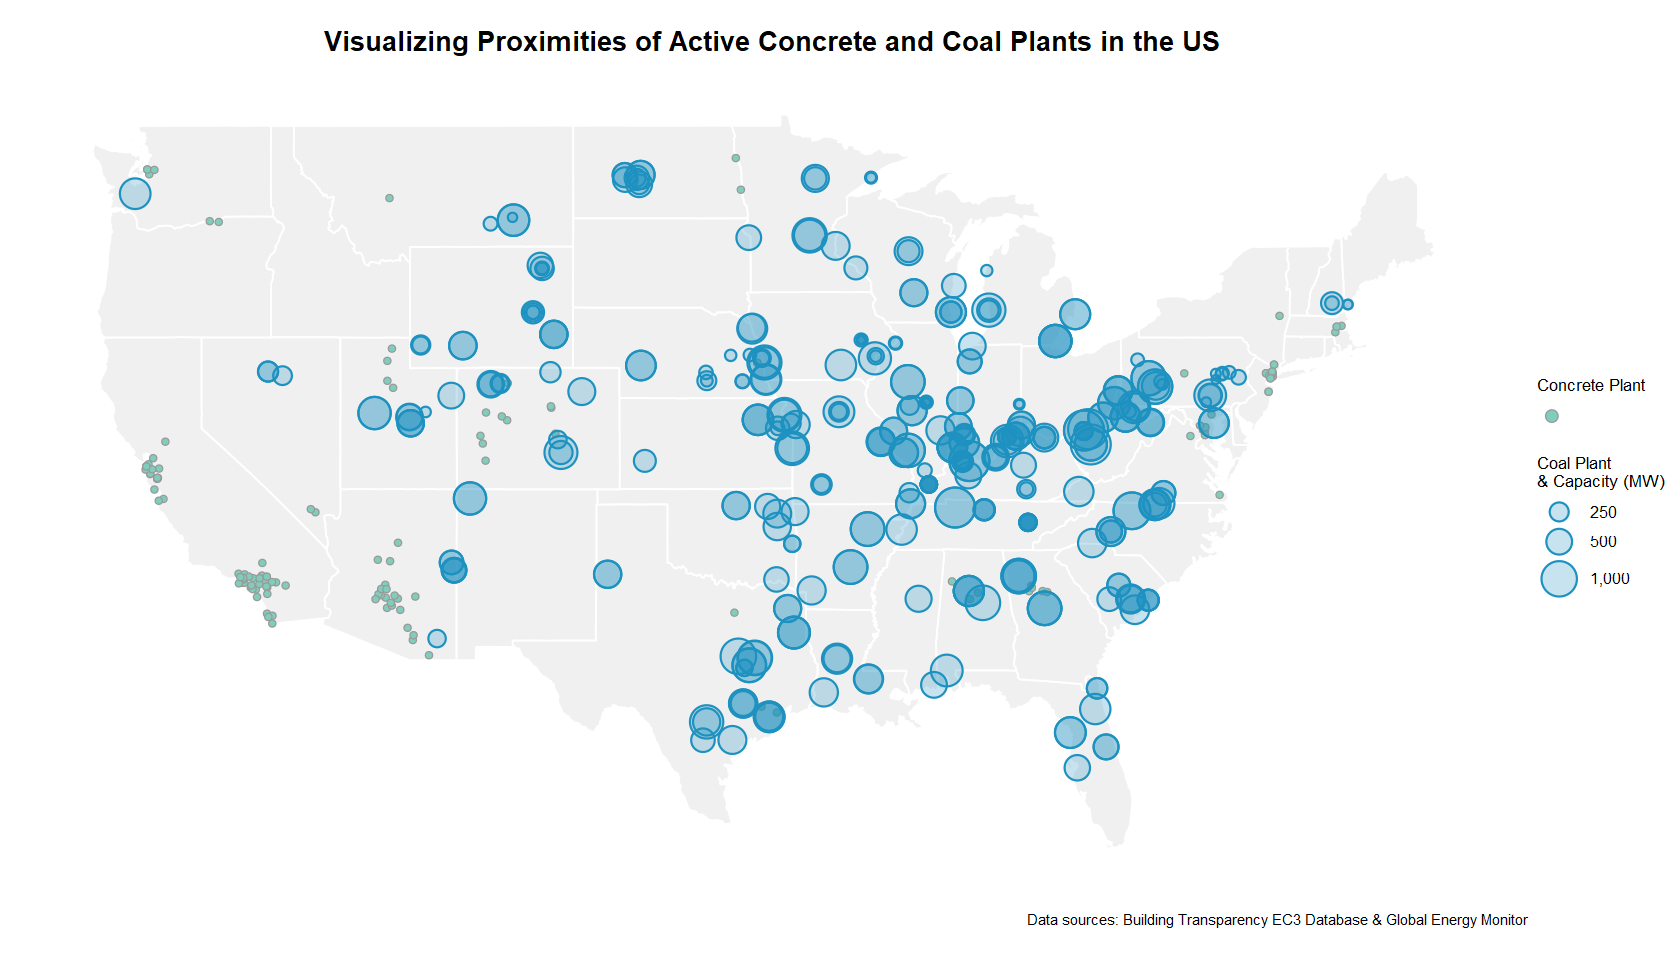

In [8]:
# VISUALIZATION 3: US Coal Plants Map

options(repr.plot.width = 14, repr.plot.height = 8)

# US state boundaries (continental 48 only)
us_states <- map_data("state")

# Filter coal plants to continental US (excludes Alaska, Hawaii, Puerto Rico, etc.)
coal_continental <- coal_plant_data %>%
  filter(
    Latitude  >= 24.5 & Latitude  <= 49.5,
    Longitude >= -125  & Longitude <= -66.5
  )

viz3 <- ggplot() +
  # State polygons
  geom_polygon(
    data      = us_states,
    aes(x = long, y = lat, group = group),
    fill      = "#f0f0f0",
    color     = "white",
    linewidth = 0.4
  ) +
  # Concrete plants: small fixed dots (rendered first so coal plants draw on top)
  geom_point(
    data   = concrete_plants,
    aes(x = `plant_or_group.longitude`, y = `plant_or_group.latitude`,
        fill = "Concrete Plant"),
    shape  = 21,
    color  = "grey60",
    size   = 1.5,
    stroke = 0.4
  ) +
  # Coal plants: circle size scaled to capacity
  geom_point(
    data   = coal_continental,
    aes(x = Longitude, y = Latitude, size = `Capacity (MW)`),
    shape  = 21,
    fill   = scales::alpha("#1d91c0", 0.25),
    color  = "#1d91c0",
    stroke = 0.7
  ) +
  # Fill legend for concrete plants
  scale_fill_manual(
    name   = "Concrete Plant",
    values = c("Concrete Plant" = "#7fcdbb"),
    labels = "",
    guide  = guide_legend(
      override.aes = list(shape = 21, size = 3, color = "grey60", stroke = 0.4)
    )
  ) +
  # Area-proportional size scale with representative legend breaks
  scale_size_area(
    name     = "Coal Plant\n& Capacity (MW)",
    max_size = 10.5,
    breaks   = c(250, 500, 1000),
    labels   = c("250", "500", "1,000")
  ) +
  # Lock aspect ratio and clip to continental US extent
  coord_fixed(ratio = 1.3, xlim = c(-125, -66), ylim = c(24.5, 49.5)) +
  labs(
    title = "Visualizing Proximities of Active Concrete and Coal Plants in the US",
    caption = "Data sources: Building Transparency EC3 Database & Global Energy Monitor"
    ) +
  theme_void() +
  theme(
    plot.title      = element_text(hjust = 0.5, size = 16, face = "bold",
                                   margin = margin(b = 10)),
    legend.position = "right",
    legend.title    = element_text(size = 10),
    legend.text     = element_text(size = 9),
    plot.background = element_rect(fill = "white", color = NA),
    plot.margin     = margin(10, 10, 10, 10),
    legend.spacing.y = unit(15, "pt")
  )

viz3

In [9]:
### use ggsave to save viz3 to the tests folder
ggsave("../tests/M15_viz3.png", viz3, width = 14, height = 8, dpi = 300)

### Caption for Visualization 3
This visualization maps Concrete plants with mixes containing fly ash and coal plants so that we can see potential relationships. It's interesting to see some of the heavier clusterings of concrete plants using fly ash are on the coasts and separated from many of the coal plants that tend to be clustered in the middle of the country.

**Figure 3:** Visualizing Proximities of Concrete and Coal Plants in the US

---

## Reflection Questions (5 points)

Answer the following questions in 2-4 sentences each.

### Question 1
**How do your three visualizations work together to tell a story about your capstone project?**

The first two visualizations work closely together in that they help to narrow in on the distribution of EPDs with fly ash used as a Supplmentary Cementitious Material (SCM), and how much of that material is used. Ultimately, the emissions from transporting fly ash will be related to the mass of the fly ash being transported, so these charts help us begin to understand both the weight and the impacts prior to considering transportation. The mapping in visualization 3 introduces the coal plant location dataset, which allows us to begin to see where plants are clustered. A future step will be to conduct a shortest path analysis between some of these points.


### Question 2
**Which visualization was most challenging to create, and why?**

Visualization #2 was challenging for me since I went through multiple iterations of tweaking the jitter and bucketing to get it to look right. In this visualization I'm also trying to communicate the relationship between three different metrics at once, so the use of a color scale was introduced. While the resulting chart is perhaps somewhat intuitive for an expert in in the field, I was also trying to develop something that can communicate to a broader audience who may not understand the relationships between these three variables.


### Question 3
**What is one thing you would improve about your visualizations if you had more time?**

The first two visuals I see more as tools for better identifying where to focus the research. The mapping in visual #3 is the next step I want to begin pushing further. It's currently a helpful visual, but is a bit deceiving since the concrete plant locations are based on EPDs, which tend to be incentivized in certain regions (ex: California) more than others. I'm thinking the mapping can be improved by maybe zooming in on some of the clusters of concrete plants and highlighting the nearest active coal plantsbased on a shortest path analysis.


---

## Grading Rubric (50 points total)

| Component | Points | Criteria |
|-----------|--------|----------|
| Visualization 1 | 15 | Appropriate type, clear labels, meaningful use of color, insightful caption |
| Visualization 2 | 15 | Shows relationship/comparison clearly, proper formatting, informative caption |
| Visualization 3 | 15 | Shows change effectively, proper time/space formatting, relevant caption |
| Reflection | 5 | Thoughtful answers demonstrating understanding of visualization choices |

### What makes a visualization "publication quality"?
- Readable fonts and appropriate sizing
- Clear hierarchy (title > subtitle > labels > caption)
- Minimal chart junk (no unnecessary gridlines, borders, or decoration)
- Accessible colors (consider colorblind-friendly palettes)
- Self-contained (a reader can understand it without reading surrounding text)

---

## Helpful Code Snippets

### Formatting dates on x-axis
```r
scale_x_date(date_labels = "%b %Y", date_breaks = "3 months")
```

### Adding a trend line
```r
geom_smooth(method = "lm", se = FALSE, color = "red")
```

### Faceting by a variable
```r
facet_wrap(~category_variable, scales = "free_y")
```

### Colorblind-friendly palette
```r
scale_color_brewer(palette = "Set2")
scale_fill_viridis_d()
```

### Adding annotations
```r
annotate("text", x = date_value, y = y_value, label = "Event", hjust = 0)
geom_vline(xintercept = as.Date("2020-03-15"), linetype = "dashed")
```

### Saving high-resolution figures
```r
ggsave("figure1.png", viz1, width = 8, height = 6, dpi = 300)
```

---

## Submission

Submit the following:
1. This completed notebook (.ipynb file)
2. Three separate image files of your visualizations (.png, 300 dpi)

**Naming convention:** `LastName_FirstName_capstone_viz.ipynb`